In [6]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [7]:
iris = load_iris()

In [13]:
X = iris.data
y = iris.target

# X = pd.DataFrame(iris.data)
# X.columns = iris.feature_names
# y = iris.target
# X.head()

<Axes: >

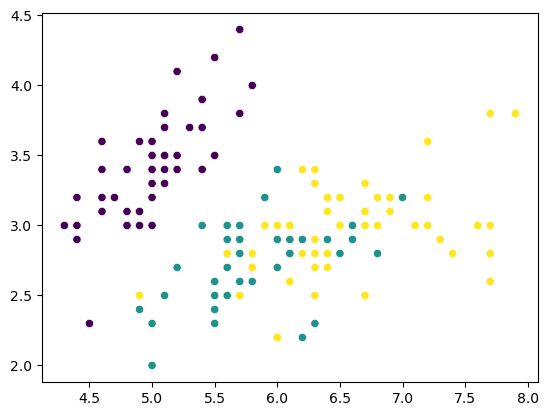

In [14]:
sns.scatterplot(x = X[:,0],y =X[:,1],c=y)

<Axes: >

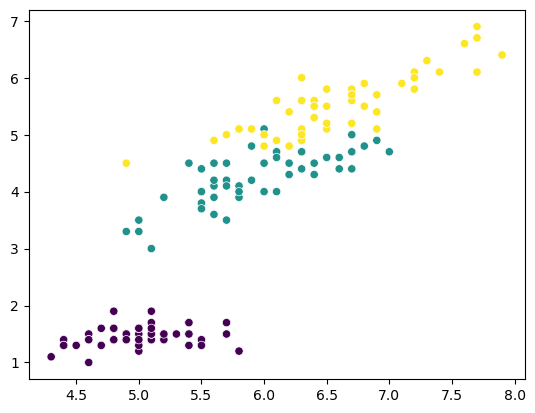

In [15]:
sns.scatterplot(x = X[:,0],y =X[:,2],c=y)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
# optional - dimensionality reduction using pca

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)


In [33]:
# Elbow Method
wcss = []

for k in range(1,11):
    kmeans =KMeans(n_clusters =k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

<Axes: >

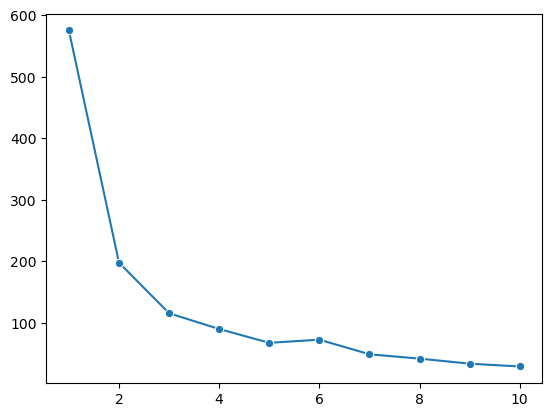

In [34]:
sns.lineplot(x=range(1,11),y=wcss ,marker='o')

C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

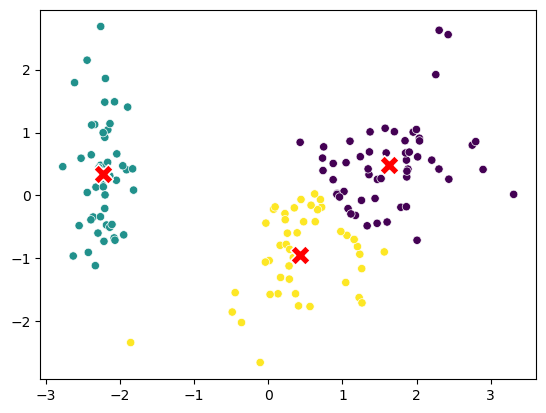

In [35]:
kmeans = KMeans(n_clusters =3,random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x = pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x = kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1],marker='X',c='red',s=200)
